# 🦥 **FineTuning With Unsloth**

###  we'll finetune the `Llama-3.2-3B-Instruct` model using unsloth on the [ServiceNow-AI/R1-Distill-SFT](https://huggingface.co/datasets/ServiceNow-AI/R1-Distill-SFT) dataset to empower the llama model with DeepSeek-R1 like 'thinking' capabilities.

Let's start with installing the dependencies.

In [ ]:
!pip install unsloth -q

Load a quantized Llama 3.2 model using Unsloth's FastLanguageModel for efficient inference/training.

In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048 # Choose any! Unsloth also supports RoPE (Rotary Positinal Embedding) scaling internally.
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage. Can be False.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct", # or choose "unsloth/Llama-3.2-1B-Instruct"
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit, # Will load the 4Bit Quantized Model
)

- `model_name`:Specifies the name of the pre-trained model to load.
- `max_seq_length`:Defines the maximum sequence length (in tokens) that the model can process. max_seq_length = 2048 allows the model to process sequences up to 2048 tokens long.
- `dtype`:Specifies the data type for model weights and computations.
   None: Automatically selects the appropriate data type based on the hardware.
   torch.float16: Uses 16-bit floating point precision, reducing memory usage and potentially increasing speed on compatible GPUs.
   torch.bfloat16: Similar to float16 but with a wider dynamic range, beneficial for certain hardware like NVIDIA A100 GPUs.
- `load_in_4bit`:Determines whether to load the model using 4-bit quantization.Ideal for scenarios where memory efficiency is crucial, such as deploying models on edge devices or during experimentation.

Now, we'll use the `get_peft_model` from unsloth's `FastLanguageModel` class to attach adapters (peft layers) on top of the models in order to perform QLoRA

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16, # a higher alpha value assigns more weight to the LoRA activations
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

<img src="w_formula.jpg"></img>

- `r`: The rank of the low-rank matrices in LoRA; higher values can capture more information but increase memory usage.
- `target_modules`: List of model components (e.g., "q_proj", "k_proj") where LoRA adapters are inserted for fine-tuning.
- `lora_alpha`: Scaling factor for the LoRA updates; controls the impact of the adapters on the model's outputs.
- `lora_dropout`: Dropout rate applied to LoRA layers during training to prevent overfitting.
- `bias`: Specifies how biases are handled in LoRA layers; options include "none", "all", or "lora_only".
- `use_gradient_checkpointing`: Enables gradient checkpointing to reduce memory usage during training; "unsloth" uses Unsloth's optimized version.
- `random_state`: Seed for random number generators to ensure reproducibility of training results.
- `use_rslora`: Boolean indicating whether to use Rank-Stabilized LoRA (rsLoRA) for potentially more stable training.
- `
loftq_config: Configuration for Low-Rank Quantization (LoftQ); set to None to disable this feature.

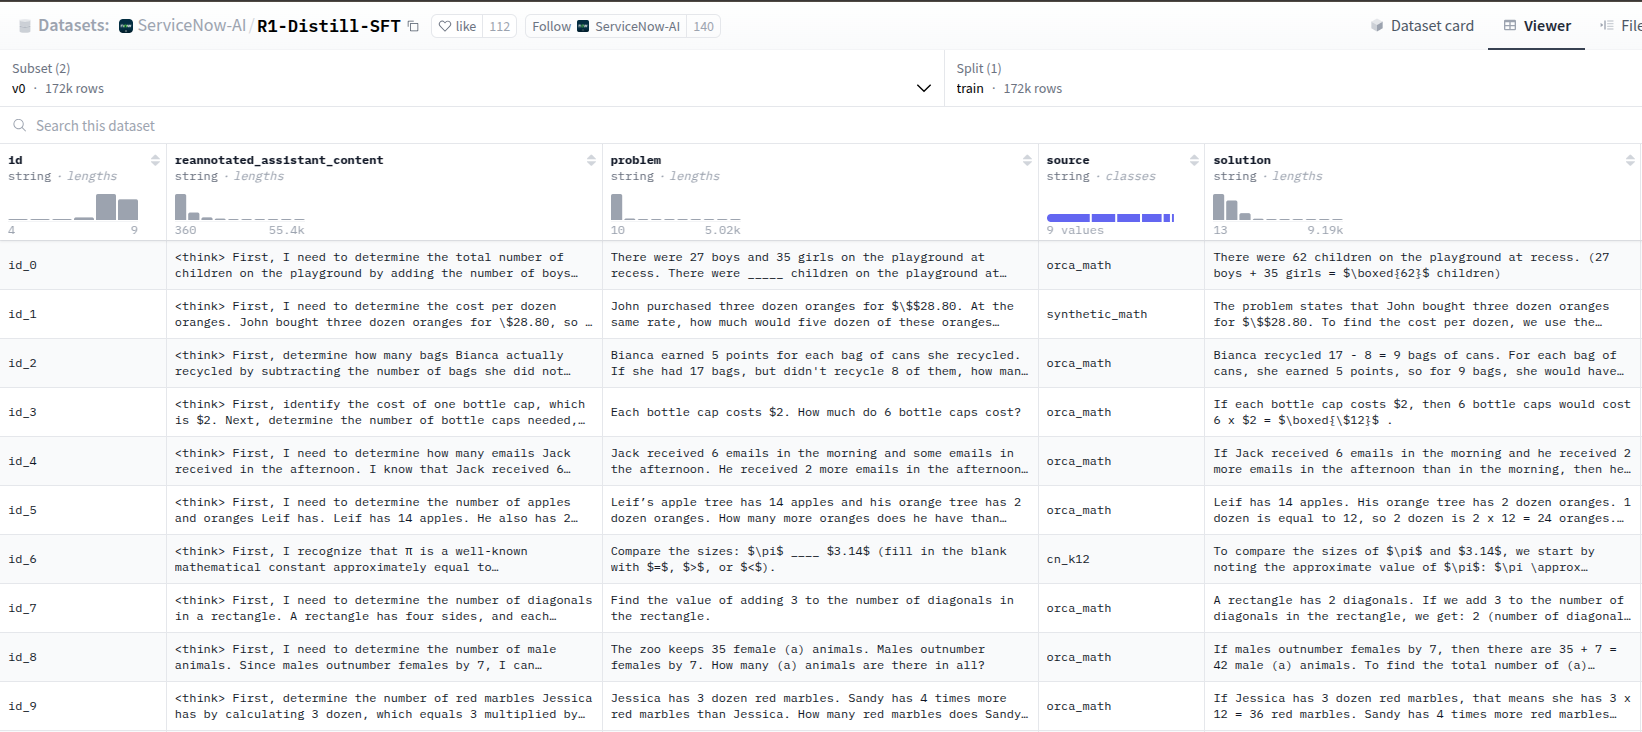

In [ ]:
from datasets import load_dataset
dataset = load_dataset("ServiceNow-AI/R1-Distill-SFT",'v0', split = "train")

In [ ]:
print(dataset[:5])

Now, we create a prompt template that will be used to finetune our Llama model

In [ ]:
r1_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
{}
</problem>

{}
{}
"""
EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(examples):
  problems = examples["problem"]
  thoughts = examples["reannotated_assistant_content"]
  solutions = examples["solution"]
  texts = []

  for problem, thought, solution in zip(problems, thoughts, solutions):
    text = r1_prompt.format(problem, thought, solution)+EOS_TOKEN
    texts.append(text)

  return {"text": texts}

dataset = dataset.map(formatting_prompts_func, batched = True,)

**Trainer Setup:**
- `model` and `tokenizer`: These are the model and tokenizer objects that will be trained.

- `train_dataset`: The dataset used for training.

- `dataset_text_field`: Specifies the field in the dataset that contains the text data.

- `max_seq_length`: Maximum sequence length for the input data.

- `dataset_num_proc`: Number of processes to use for data loading.

- `packing`: If True, enables sequence packing (concatenates multiple examples into a single sequence to better utilize tokens).


**Training Arguments:**
- `per_device_train_batch_size`: Number of samples per batch for each device.

- `gradient_accumulation_steps`: Number of steps to accumulate gradients before updating model weights.

- `warmup_steps`: Number of steps for learning rate warmup.

- `max_steps`: Total number of training steps.

- `learning_rate`: Learning rate for the optimizer.

- `fp16` and `bf16`: Specifies whether to use 16-bit floating point precision or bfloat16, depending on hardware support.

- `logging_steps`: Frequency of logging training progress.

- `optim`: Optimizer type, here using an 8-bit version of AdamW.

- `weight_decay`: Regularization parameter for weight decay.

- `lr_scheduler_type`: Type of learning rate scheduler.

- `seed`: Random seed for reproducibility.

- `output_dir`: Directory where the training outputs will be saved.

- `report_to`: Integration for observability tools like "wandb", "tensorboard", etc.

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2, # Number of processors to use for processing the dataset
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2, # The batch size per GPU/TPU core
        gradient_accumulation_steps = 4, # Number of steps to perform befor each gradient accumulation
        warmup_steps = 5, # Few updates with low learning rate before actual training
        max_steps = 60, # Specifies the total number of training steps (batches) to run.
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit", # Optimizer
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc for observability
    ),
)

In [ ]:
trainer_stats = trainer.train()

In [ ]:
from unsloth.chat_templates import get_chat_template
sys_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
{}
</problem>
"""
message = sys_prompt.format("How many 'r's are present in 'strawberry'?")
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": message},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 1024, use_cache = True,
                         temperature = 1.5, min_p = 0.1)
response = tokenizer.batch_decode(outputs)

In [ ]:
print(response[0])

In [ ]:
model.save_pretrained("chintan-001-3B")  # Local saving
tokenizer.save_pretrained("chintan-001-3B")

In [ ]:
model.save_pretrained_gguf("chintan-001-3B-GGUF", tokenizer,)

### **Running the model via Ollama (OPTIONAL)**

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

In [ ]:
import subprocess
subprocess.Popen(["ollama", "serve"])
import time
time.sleep(3)

In [ ]:
print(tokenizer._ollama_modelfile)

In [ ]:
!ollama create unsloth_model -f ./chintan-001-3B-GGUF/Modelfile